In [31]:
from collections.abc import Iterable

In [2]:
import numpy as np

# 1. Setup small corpus
corpus = [
    ["data", "science", "is", "fun"],
    ["data", "is", "power"]
]
vocab = ["data", "science", "is", "fun", "power"]

# 2. Create the TF Matrix (Rows=Docs, Cols=Vocab)
tf_matrix = np.array([
    [doc.count(word) / len(doc) for word in vocab] 
    for doc in corpus
])

# 3. Calculate IDF (Global)
N = len(corpus)
# Count how many docs contain each word
df = np.array([sum(1 for doc in corpus if word in doc) for word in vocab])
idf = np.log(N / df)

# 4. Final TF-IDF (Broadcasting multiplication)
tfidf_matrix = tf_matrix * idf

print("Vocabulary:", vocab)
print("TF-IDF Matrix:\n", tfidf_matrix)
print (f"tf matrix :{tf_matrix}")

Vocabulary: ['data', 'science', 'is', 'fun', 'power']
TF-IDF Matrix:
 [[0.         0.1732868  0.         0.1732868  0.        ]
 [0.         0.         0.         0.         0.23104906]]
tf matrix :[[0.25       0.25       0.25       0.25       0.        ]
 [0.33333333 0.         0.33333333 0.         0.33333333]]


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Example corpus
corpus = ["data science is fun.", "data is power."]

# Initialize the TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the corpus
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

# Get feature names (vocabulary)
vocab = tfidf_vectorizer.get_feature_names_out()

# Convert the TF-IDF matrix  to a dense format and print
print("Vocabulary:", vocab)
print("TF-IDF Matrix:")
print(tfidf_matrix.toarray())

Vocabulary: ['data' 'fun' 'is' 'power' 'science']
TF-IDF Matrix:
[[0.40993715 0.57615236 0.40993715 0.         0.57615236]
 [0.50154891 0.         0.50154891 0.70490949 0.        ]]


In [12]:
import pandas as pd
import random

data = {
    "text": [
        "I am really worried about the recent market volatility and my portfolio performance.",
        "The onboarding process was seamless, thanks for the help.",
        "Can we schedule a call to discuss the management fees on my account?",
        "I’m very happy with the dividends we’ve seen this quarter.",
        "I need to update my beneficiary information on the life insurance policy.",
        # ... generate more variations here
    ],
    "category": ["negative", "positive", "negative", "positive", "neutral"] * 1  # Expand to 100+
}

df = pd.DataFrame(data)




In [13]:
from transformers import pipeline

# This will run efficiently on your CPU
classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

def get_sentiment(text):
    result = classifier(text)[0]
    return result['label'], result['score']

df['sentiment'], df['score'] = zip(*df['text'].apply(get_sentiment))




Loading weights: 100%|███████████████████████████████████████████████████████| 104/104 [00:00<00:00, 958.74it/s]


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=1000, stop_words='english')
X = vectorizer.fit_transform(df['text'])

from sklearn.linear_model import LogisticRegression
df['label'] = df['sentiment'].apply(lambda x: 1 if x == 'POSITIVE' else 0)
model = LogisticRegression()
model.fit(X, df['label'])

feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]
top_10_positive = sorted(zip(feature_names, coefficients), key=lambda x: x[1], reverse=True)[:10]
top_10_negative = sorted(zip(feature_names, coefficients), key=lambda x: x[1])[:10]

# create wordcloud data with top 10 positive and negative words


# for word, __coef in zip(feature_names, coefficients):
#     print(f"{word}: {__coef:.4f}, {'positive' if __coef > 0 else 'negative'}")


print(f"\nTop 5 Positive Words: {top_10_positive}")
print(f"Top 5 Negative Words: {top_10_negative}")


account: -0.1076, negative
beneficiary: -0.0895, negative
beneficiary information: -0.0895, negative
discuss: -0.1076, negative
discuss management: -0.1076, negative
dividends: 0.1610, positive
dividends ve: 0.1610, positive
fees: -0.1076, negative
fees account: -0.1076, negative
happy: 0.1610, positive
happy dividends: 0.1610, positive
help: 0.1610, positive
information: -0.0895, negative
information life: -0.0895, negative
insurance: -0.0895, negative
insurance policy: -0.0895, negative
life: -0.0895, negative
life insurance: -0.0895, negative
management: -0.1076, negative
management fees: -0.1076, negative
market: -0.0895, negative
market volatility: -0.0895, negative
need: -0.0895, negative
need update: -0.0895, negative
onboarding: 0.1610, positive
onboarding process: 0.1610, positive
performance: -0.0895, negative
policy: -0.0895, negative
portfolio: -0.0895, negative
portfolio performance: -0.0895, negative
process: 0.1610, positive
process seamless: 0.1610, positive
quarter: 0.

In [33]:

def wordcloud(top_10_negative: dict, top_10_positive: dict):
    from wordcloud import WordCloud
    import matplotlib.pyplot as plt

    # Create wordcloud data for top 10 positive and negative words
    #positive_wordcloud_data = {word: abs(coef) for word, coef in top_10_positive}
    #negative_wordcloud_data = {word: abs(coef) for word, coef in top_10_negative}

    # Generate wordclouds
    positive_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_10_positive)
    negative_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_10_negative)

    # Plot the wordclouds
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Top 10 Positive Words")
    plt.imshow(positive_wordcloud, interpolation='bilinear')
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Top 10 Negative Words")
    plt.imshow(negative_wordcloud, interpolation='bilinear')
    plt.axis("off")

    plt.show()

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np

def generate_embeddings(text):
    # 1. Load the model and tokenizer
    model_name = "distilbert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)

    # 2. Prepare your text
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)

    # 3. Generate Embeddings (No gradient needed as we aren't training)
    with torch.no_grad():
        outputs = model(**inputs)

    # The 'last_hidden_state' contains the embeddings
    # Shape: [batch_size, sequence_length, hidden_size] (e.g., [1, 9, 768])
    last_hidden_states = outputs.last_hidden_state

    # 4. Perform Mean Pooling to get one vector for the sentence
    sentence_embedding = torch.mean(last_hidden_states, dim=1).squeeze().numpy()  # Shape: [hidden_size] (e.g., [768])
    print(f"Embedding Shape: {sentence_embedding.shape}")
    #print(f"First 5 values: {sentence_embedding[0][:5]}")
    return sentence_embedding



df['embedding'] = df['text'].apply(generate_embeddings)
X_dense = np.stack(df['embedding'].values)
print(f"shape : {X_dense.shape}")  # Should be (num_samples, hidden_size) e.g., (100, 768)

from sklearn.linear_model import LogisticRegression
df['label'] = df['sentiment'].apply(lambda x: 1 if x == 'POSITIVE' else 0)
y = df['label']

model = LogisticRegression(max_iter=1000)
model.fit(X_dense, y)

# from sklearn.feature_extraction.text import TfidfVectorizer

# vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=1000, stop_words='english')
# X = vectorizer.fit_transform(df['text'])





# feature_names = vectorizer.get_feature_names_out()
# coefficients = model.coef_[0]
# top_10_positive = sorted(zip(feature_names, coefficients), key=lambda x: x[1], reverse=True)[:10]
# top_10_negative = sorted(zip(feature_names, coefficients), key=lambda x: x[1])[:10]

# create wordcloud data with top 10 positive and negative words

from sklearn.metrics.pairwise import cosine_similarity

# Compare "Market volatility" sentence with "Portfolio performance" sentence
sent1 = df['embedding'].iloc[0].reshape(1, -1)
sent2 = df['embedding'].iloc[2].reshape(1, -1)

similarity = cosine_similarity(sent1, sent2)
print(f"Semantic Similarity: {similarity[0][0]:.4f}")
#label the df with  'position' and 'negative' 
for word, __coef in zip(feature_names, coefficients):
    print(f"{word}: {__coef:.4f}, {'positive' if __coef > 0 else 'negative'}")


print(f"\nTop 5 Positive Words: {top_10_positive}")
print(f"Top 5 Negative Words: {top_10_negative}")



Loading weights: 100%|██████████████████████████████████████████████████████| 100/100 [00:00<00:00, 2574.27it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding Shape: (768,)


Loading weights: 100%|██████████████████████████████████████████████████████| 100/100 [00:00<00:00, 2159.53it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding Shape: (768,)


Loading weights: 100%|██████████████████████████████████████████████████████| 100/100 [00:00<00:00, 1798.53it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding Shape: (768,)


Loading weights: 100%|██████████████████████████████████████████████████████| 100/100 [00:00<00:00, 1312.45it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding Shape: (768,)


Loading weights: 100%|██████████████████████████████████████████████████████| 100/100 [00:00<00:00, 1900.24it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding Shape: (768,)
shape : (5, 768)
Semantic Similarity: 0.7938


NameError: name 'feature_names' is not defined

In [7]:
df.head()

,text,category,sentiment,score
0,I am really worried about the recent market vo...,negative,NEGATIVE,0.997869
1,"The onboarding process was seamless, thanks fo...",positive,POSITIVE,0.998742
2,Can we schedule a call to discuss the manageme...,negative,NEGATIVE,0.998746
3,I’m very happy with the dividends we’ve seen t...,positive,POSITIVE,0.999794
4,I need to update my beneficiary information on...,neutral,NEGATIVE,0.999018


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Sample Data
reviews = ["The food was great", "The food was terrible", "Great service", "Terrible service"]
labels = [1, 0, 1, 0] # 1=Pos, 0=Neg

# 1. TF-IDF Transformation
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(reviews)

# 2. Train a simple linear model
model = LogisticRegression()
model.fit(X, labels)

print("X", X.toarray())
print("Coefficients:", model.coef_)

# 3. Match words to their "Sentiment Weight"
words = vectorizer.get_feature_names_out()
print("Words:", words)
weights = model.coef_[0]

for word, weight in zip(words, weights):
    sentiment = "Positive" if weight > 0 else "Negative"
    print(f"Word: {word:10} | Weight: {weight:.4f} | Sentiment: {sentiment}")

X [[0.5        0.5        0.         0.         0.5        0.5       ]
 [0.5        0.         0.         0.5        0.5        0.5       ]
 [0.         0.70710678 0.70710678 0.         0.         0.        ]
 [0.         0.         0.70710678 0.70710678 0.         0.        ]]
Coefficients: [[-2.35911723e-17  5.08968850e-01  5.02469069e-18 -5.08968850e-01
  -2.35911723e-17 -2.35911723e-17]]
Words: ['food' 'great' 'service' 'terrible' 'the' 'was']
Word: food       | Weight: -0.0000 | Sentiment: Negative
Word: great      | Weight: 0.5090 | Sentiment: Positive
Word: service    | Weight: 0.0000 | Sentiment: Positive
Word: terrible   | Weight: -0.5090 | Sentiment: Negative
Word: the        | Weight: -0.0000 | Sentiment: Negative
Word: was        | Weight: -0.0000 | Sentiment: Negative


In [16]:
df

,text,category,sentiment,score
0,I am really worried about the recent market vo...,negative,NEGATIVE,0.997869
1,"The onboarding process was seamless, thanks fo...",positive,POSITIVE,0.998742
2,Can we schedule a call to discuss the manageme...,negative,NEGATIVE,0.998746
3,I’m very happy with the dividends we’ve seen t...,positive,POSITIVE,0.999794
4,I need to update my beneficiary information on...,neutral,NEGATIVE,0.999018


In [ ]:
# 1. Prepare your data structure
token_data = []
for index, row in df.iterrows():
    # Simple tokenization (you can use your tokenizer here)
    tokens = row['text'].lower().split() 
    label = row['sentiment'] 
    
    for token in tokens:
        token_data.append({'token': token, 'label': label})

#2 apply n gram tokenization and create a new column in the df with the n-grams
from sklearn.feature_extraction.text import CountVectorizer


# 2. Convert to DataFrame
token_df = pd.DataFrame(token_data)

# 3. Apply Naive Bayes
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# CountVectorizer is better than TF-IDF for Naive Bayes
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(token_df['token'])
y = token_df['label']

model = MultinomialNB()
model.fit(X, y)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [7]:
y_pred = model.predict(vectorizer.transform(["market", "volatility"]))
print(f"Predicted Sentiment for 'market volatility': {y_pred[0]}")
print(token_df.head())

Predicted Sentiment for 'market volatility': NEGATIVE
     token     label
0        i  NEGATIVE
1       am  NEGATIVE
2   really  NEGATIVE
3  worried  NEGATIVE
4    about  NEGATIVE


Features: ['beneficiary information' 'beneficiary information life'
 'discuss management' 'discuss management fees' 'dividends ve'
 'dividends ve seen' 'fees account' 'happy dividends' 'happy dividends ve'
 'information life' 'information life insurance' 'insurance policy'
 'life insurance' 'life insurance policy' 'management fees'
 'management fees account' 'market volatility'
 'market volatility portfolio' 'need update' 'need update beneficiary'
 'onboarding process' 'onboarding process seamless'
 'portfolio performance' 'process seamless' 'process seamless thanks'
 'really worried' 'really worried recent' 'recent market'
 'recent market volatility' 'schedule discuss'
 'schedule discuss management' 'seamless thanks' 'seamless thanks help'
 'seen quarter' 'thanks help' 'update beneficiary'
 'update beneficiary information' 've seen' 've seen quarter'
 'volatility portfolio' 'volatility portfolio performance'
 'worried recent' 'worried recent market']

Top 10 Positive Words: ['ve seen'

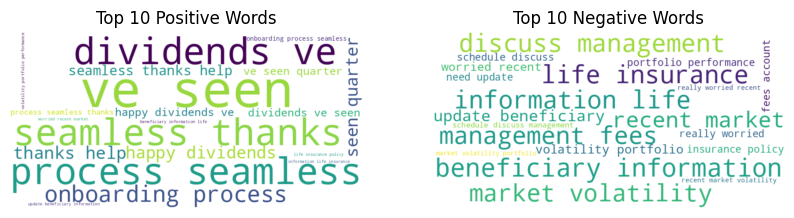

In [40]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# count vectorizer with n-grams (2 to 3) and stop words removal
vectorizer = CountVectorizer(ngram_range=(2, 3), stop_words='english')

def tokenize_and_label(text, label):
    tokens = vectorizer.build_analyzer()(text)
    return tokens, label

# apply the vectorizer to the 'text' column and create a new column 'token' with the n-grams and apply the sentiment label to each token
df_token_and_label = pd.DataFrame(columns=['token', 'label'])
#print(df)
abc: dict = {}
for index, row in df.iterrows():
    tokens, label = tokenize_and_label(row['text'], row['sentiment'])
    #print(f"Tokens: {tokens}, Label: {label}")
    # for all token in the tokens list, create a new row in the df with the token and the label
    for token in tokens:
        abc[token] = label
    #print(abc)

#X = df_token_and_label.apply(lambda x: " ".join([token for token, label in x]))
#y = df['sentiment']
# if a key appears multiple time with different labels then remove the key from the dict abc
key_to_remove = [key for key, value in abc.items() if isinstance(value, list) and len(set(value)) > 1]
for key in key_to_remove:
    del abc[key]
# create a new df with the token and the label
df_token_and_label = pd.DataFrame(list(abc.items()), columns=['token', 'label'])

# now apply multinomial naive bayes on the df_token_and_label with the token as the feature and the label as the target variable
classifier = MultinomialNB()
X = vectorizer.fit_transform(df_token_and_label['token'])
y = df_token_and_label['label']
features = vectorizer.get_feature_names_out()
print(f"Features: {features}")
classifier.fit(X, y)

# 3. Extract Log-Probabilities
# feature_log_prob_ has shape [n_classes, n_features]
# Usually, index 0 is Negative and index 1 is Positive
neg_log_prob = classifier.feature_log_prob_[0]
pos_log_prob = classifier.feature_log_prob_[1]

# calculate the ratio of positive to negative log-probabilities for each feature
log_prob_ratio = pos_log_prob - neg_log_prob

sorted_indices = log_prob_ratio.argsort()
top_20_positive = sorted_indices[-20:][::-1]
top_20_negative = sorted_indices[:20]

print(f"\nTop 10 Positive Words: {[features[i] for i in top_20_positive]}")
print(f"Top 10 Negative Words: {[features[i] for i in top_20_negative]}")

wordcloud(top_10_negative={features[i]: abs(log_prob_ratio[i]) for i in top_20_negative},
          top_10_positive={features[i]: abs(log_prob_ratio[i]) for i in top_20_positive})


